# Data Preparation Techniques

### Definition

Data preparation in time series involves modifying, cleaning, or restructuring the dataset to make it suitable for analysis and forecasting.

### Concept

In time series, raw data often needs:

Resampling: Changing the frequency of data points.

Interpolation: Filling missing values when frequency is increased or data is incomplete.

Transformation: Applying mathematical functions to stabilize variance or make the series more linear.

### Part 1 — Resampling

Why

Sometimes data is recorded at the wrong frequency for your analysis (e.g., daily when you need monthly, or monthly when you need daily).

Types

Upsampling: Increase frequency (e.g., monthly → daily). Requires filling missing values.

Downsampling: Decrease frequency (e.g., daily → monthly average).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create monthly sales data for one year
dates = pd.date_range(start="2023-01-01", periods=12, freq='MS')  # 'MS' = Month Start

sales = [200, 220, 250, 270, 300, 320, 310, 305, 330, 350, 370, 400]

df_monthly = pd.DataFrame({"Sales": sales}, index=dates)
df_monthly

,Sales
2023-01-01,200
2023-02-01,220
2023-03-01,250
2023-04-01,270
2023-05-01,300
2023-06-01,320
2023-07-01,310
2023-08-01,305
2023-09-01,330
2023-10-01,350


In [3]:
# 1. Upsampling: Monthly → Daily
df_daily = df_monthly.resample('D').mean()  # creates NaN for in-between days

# .resample('freq') → changes the frequency (e.g., 'D' = day, 'Q' = quarter).


df_daily

,Sales
2023-01-01,200.0
2023-01-02,NaN
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
...,...
2023-11-27,NaN
2023-11-28,NaN
2023-11-29,NaN
2023-11-30,NaN


In [6]:
# 2. Downsampling: Monthly → Quarterly (average)
df_quarterly = df_monthly.resample('QE').mean()
# .mean() after resampling calculates average for each period.

# Upsampling produces NaNs for missing points (needs interpolation).

df_quarterly

,Sales
2023-03-31,223.333333
2023-06-30,296.666667
2023-09-30,315.000000
2023-12-31,373.333333


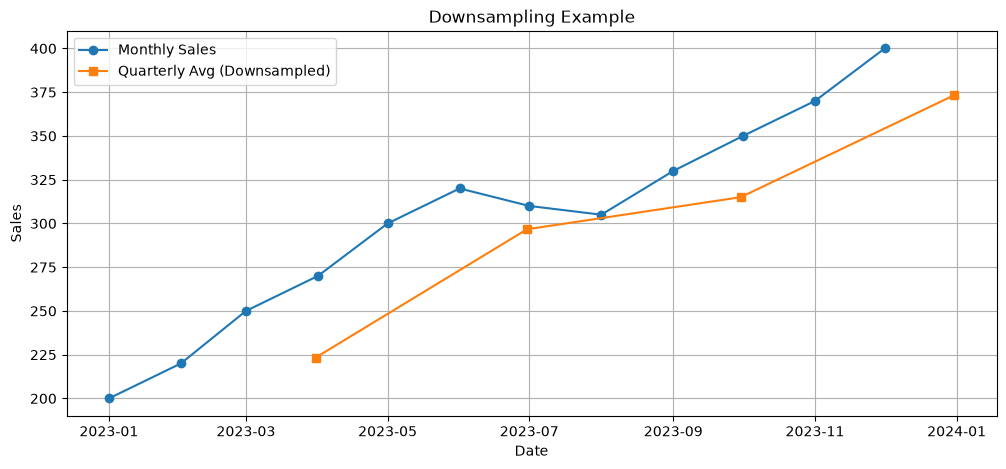

In [7]:
# Plot results
plt.figure(figsize=(12,5))

plt.plot(df_monthly.index, df_monthly["Sales"], marker='o', label="Monthly Sales")

plt.plot(df_quarterly.index, df_quarterly["Sales"], marker='s', label="Quarterly Avg (Downsampled)")
plt.title("Downsampling Example")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()